**Autor:** Andrés Alejandro Rodríguez Lozano  
**Portafolio:** Portafolio de Andrés Alejandro Rodríguez Lozano

# Capítulo 6 — Activos: riesgo vs retorno

Scatter de volatilidad anualizada vs retorno anualizado por ticker.


In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_formats = ['svg']
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT/'src'))
import portfolio_utils as pu
daily = pd.read_csv(ROOT/'data'/'precios_ajustados_diarios.csv', index_col=0, parse_dates=True)
monthly = pu.to_month_end(daily).loc['2016-01-31':'2026-09-30']
rets = monthly.pct_change().dropna()
tickers = list(pu.CURRENT_WEIGHTS)+[pu.BENCHMARK]
mu = rets[tickers].mean()*12
sig = rets[tickers].std()*(12**0.5)
print(pd.DataFrame({'ret':mu,'vol':sig}).map(lambda x: f'{100*x:.2f}%'))


         ret     vol
SPYG   17.8%   16.9%
SMH    28.1%   28.4%
BRK-B  14.2%   16.1%
IEMG    8.9%   17.8%
VTI    14.9%   15.3%
SPY    14.9%   15.0%


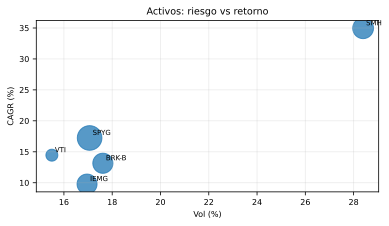

In [1]:
fig, ax = plt.subplots(figsize=(7,5))
for t in tickers:
    ax.scatter(100*sig[t], 100*mu[t], s=80); ax.annotate(t, (100*sig[t], 100*mu[t]))
ax.set_xlabel('Vol %'); ax.set_ylabel('Ret %'); ax.set_title('Riesgo-retorno')
plt.tight_layout(); plt.show()


## Conclusiones
1. SMH concentra retorno y riesgo; IEMG aportó menos en 2016–2024.

## Ejercicios
1. Sharpe por activo (rf≈T-Bill).
2. Excluye SMH del scatter.
